# 1. Kirjastot ja datan lataus

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from matplotlib.colors import LogNorm
from PIL import Image
from datetime import datetime, timedelta
import seaborn as sns
import os

# 1. TIEDOSTOJEN LATAUS
file_path = 'node_52535.csv'
img_path = 'kauppa.jpg'

file_path = '../data/raw/node_52535.csv' 

# kauppa.jpg on suoraan projektin juuressa
img_path = '../kauppa.jpg'

# Ladataan CSV-data
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    print(f"✅ Data ladattu: {len(df):,} riviä.")

    # CSV-rakenteen tarkistus
    print("\n--- CSV-RAKENNE ---")
    print(f"Sarakkeet: {list(df.columns)}")
else:
    print(f"❌ Tiedostoa {file_path} ei löytynyt!")
    print(f"Koodin nykyinen sijainti on: {os.getcwd()}") 

# Ladataan pohjakuva
if os.path.exists(img_path):
    img = Image.open(img_path)
    print(f"\n✅ Taustakuva ladattu: {img.size[0]}x{img.size[1]} px.")
else:
    print(f"\n❌ Varoitus: {img_path} puuttuu. Tarkista polku!")

✅ Data ladattu: 8,964,462 riviä.

--- CSV-RAKENNE ---
Sarakkeet: ['node_id', 'timestamp', 'x', 'y', 'z', 'q']

✅ Taustakuva ladattu: 1280x617 px.


# 2. ETL-putken valmistelu ja konfigurointi

In [2]:
store_config = {
    "geometry": {
        "store_max_x_cm": 10406,
        "store_max_y_cm": 5220,
        "image": {
            "filename": "kauppa.jpg",
            "width_px": 1280,
            "height_px": 617,
            "scale_cm_per_px": 0.11015,
            "origin_x_px": 108.7,
            "origin_y_px": 22.0,
            "invert_y": True
        },
        "timezone": "Europe/Helsinki"
    },
    "spatial_zones": {
        "gates": {
            "kassa": {"coords": (0, 800, 0, 2150), "color": "yellow", "type": "outbound"},
            "sisäänkäynti": {"coords": (0, 500, 2150, 3000), "color": "lime", "type": "inbound"}
        },
        "dead_zones": {
            "varasto": (0, 1500, 3000, 5220),
            "lastaus": (8500, 10406, 0, 500),
            "lovi": (9830, 10406, 4700, 5220),
            "latauspiste_1": (0, 300, 2300, 2700),
            "latauspiste_2": (700, 1100, 3400, 3800)
        }
    },
    "session_logic": {
        "gap_threshold_s": 300,
        "min_points": 50,              
        "min_dist_m": 50.0,            
        "max_dist_m": 5000.0,
        "min_time_s": 120,             
        "max_time_s": 5400,
        "min_store_penetration_x": 500 
    },
    "motion_filters": {
        "max_jump_speed_ms": 2.78,
        "max_avg_speed_ms": 1.5,
        "min_avg_speed_ms": 0.12       
    },
    "operational_hours": {
        "mon-sat": (8, 21),
        "sun": (9, 20)
    }
}
print("✅ Tiukennetut asetukset ladattu")

✅ Tiukennetut asetukset ladattu


## 3. ETL-putken datan siivous


In [3]:
class StoreDataCleaner:
    def __init__(self, config):
        self.config = config
        self.geom = config['geometry']
        self.logic = config['session_logic']
        self.motion = config['motion_filters']
        self.ops = config['operational_hours']
        self.gates = config['spatial_zones']['gates']

    def clean_spatial(self, df):
        mask = (df['x'] >= 0) & (df['x'] <= self.geom['store_max_x_cm']) & \
               (df['y'] >= 0) & (df['y'] <= self.geom['store_max_y_cm'])
        df = df[mask].copy()
        for name, coords in self.config['spatial_zones']['dead_zones'].items():
            x1, x2, y1, y2 = coords
            df = df[~((df['x'] >= x1) & (df['x'] <= x2) & (df['y'] >= y1) & (df['y'] <= y2))]
        return df

    def sessionize(self, df):
        df = df.sort_values(['node_id', 'timestamp'])
        df['dt'] = df.groupby('node_id')['timestamp'].diff().dt.total_seconds()
        df['new_session'] = (df['dt'] > self.logic['gap_threshold_s']) | df['dt'].isna()
        df['session_id'] = df.groupby('node_id')['new_session'].cumsum()
        df['final_sid'] = df['node_id'].astype(str) + "_" + df['session_id'].astype(str)
        return df

    def is_operational(self, timestamp):
        wd = timestamp.day_name()
        hr = timestamp.hour
        start, end = self.ops['sun'] if wd == 'Sunday' else self.ops['mon-sat']
        return start <= hr < end

    def validate_sessions(self, df):
        valid_data = []
        stats = []
        for sid, group in df.groupby('final_sid'):
            if len(group) < self.logic['min_points']: continue

            start_time = group['timestamp'].min()
            if not self.is_operational(start_time): continue

            # Tiukennettu porttilogiikka: täytyy alkaa sisäänkäynniltä JA loppua kassalle
            start_pt = group.iloc[0]
            end_pt = group.iloc[-1]

            s_x1, s_x2, s_y1, s_y2 = self.gates['sisäänkäynti']['coords']
            is_start_valid = (s_x1 <= start_pt['x'] <= s_x2) and (s_y1 <= start_pt['y'] <= s_y2)

            k_x1, k_x2, k_y1, k_y2 = self.gates['kassa']['coords']
            is_end_valid = (k_x1 <= end_pt['x'] <= k_x2) and (k_y1 <= end_pt['y'] <= k_y2)

            # Syvyysvaatimus: onko käyty riittävän syvällä myymälässä?
            max_x = group['x'].max()
            has_penetrated = max_x >= self.logic['min_store_penetration_x']

            duration = (group['timestamp'].max() - start_time).total_seconds()
            if not (self.logic['min_time_s'] <= duration <= self.logic['max_time_s']): continue

            dx, dy = group['x'].diff().fillna(0)/100, group['y'].diff().fillna(0)/100
            dist = np.sqrt(dx**2 + dy**2).sum()
            if dist < self.logic['min_dist_m']: continue

            avg_speed = dist / duration if duration > 0 else 0
            if avg_speed < self.motion['min_avg_speed_ms']: continue

            # VAATIMUS: Alku + Loppu + Syvyys
            if is_start_valid and is_end_valid and has_penetrated:
                valid_data.append(group)
                stats.append({
                    'sessio_id': sid, 'start_time': start_time, 'kesto_min': duration / 60,
                    'matka_m': dist, 'max_x': max_x, 'pisteet': len(group), 'nopeus_avg': avg_speed,
                    'pvm': start_time.date(), 'tunti': start_time.hour
                })

        return pd.concat(valid_data) if valid_data else pd.DataFrame(), pd.DataFrame(stats)

cleaner = StoreDataCleaner(store_config)
df_spatial = cleaner.clean_spatial(df)
df_sessionized = cleaner.sessionize(df_spatial)
df_final, session_metrics = cleaner.validate_sessions(df_sessionized)

print(f"✅ ETL valmis: {len(session_metrics)} tarkasti validoitua asiointia löydetty.")

✅ ETL valmis: 263 tarkasti validoitua asiointia löydetty.


# 4. Liiketoimintamittarit


In [4]:
if not session_metrics.empty:
    avg_speed_ms = session_metrics['nopeus_avg'].mean()
    avg_speed_kmh = avg_speed_ms * 3.6

    print("--- LOPULLISET LIIKETOIMINTAMITTARIT (Tiukennettu ETL) ---")
    print(f"Valideja asiointeja: {len(session_metrics)} kpl")
    print(f"Keskikesto: {session_metrics['kesto_min'].mean():.1f} min")
    print(f"Keskimatka: {session_metrics['matka_m'].mean():.1f} m")
    print(f"Keskinopeus: {avg_speed_kmh:.2f} km/h")

    # Validointitarkistus session keston rajoille
    over_limit = (session_metrics['kesto_min'] > store_config['session_logic']['max_time_s']/60).sum()
    print(f"\nYli {store_config['session_logic']['max_time_s']/60}min sessioita: {over_limit} kpl (Suodatettu pois)")
else:
    print("Varoitus: Ei valideja sessioita löytynyt nykyisillä suodattimilla.")

--- LOPULLISET LIIKETOIMINTAMITTARIT (Tiukennettu ETL) ---
Valideja asiointeja: 263 kpl
Keskikesto: 28.6 min
Keskimatka: 544.7 m
Keskinopeus: 1.30 km/h

Yli 90.0min sessioita: 0 kpl (Suodatettu pois)


# 5. Aika-analyysi

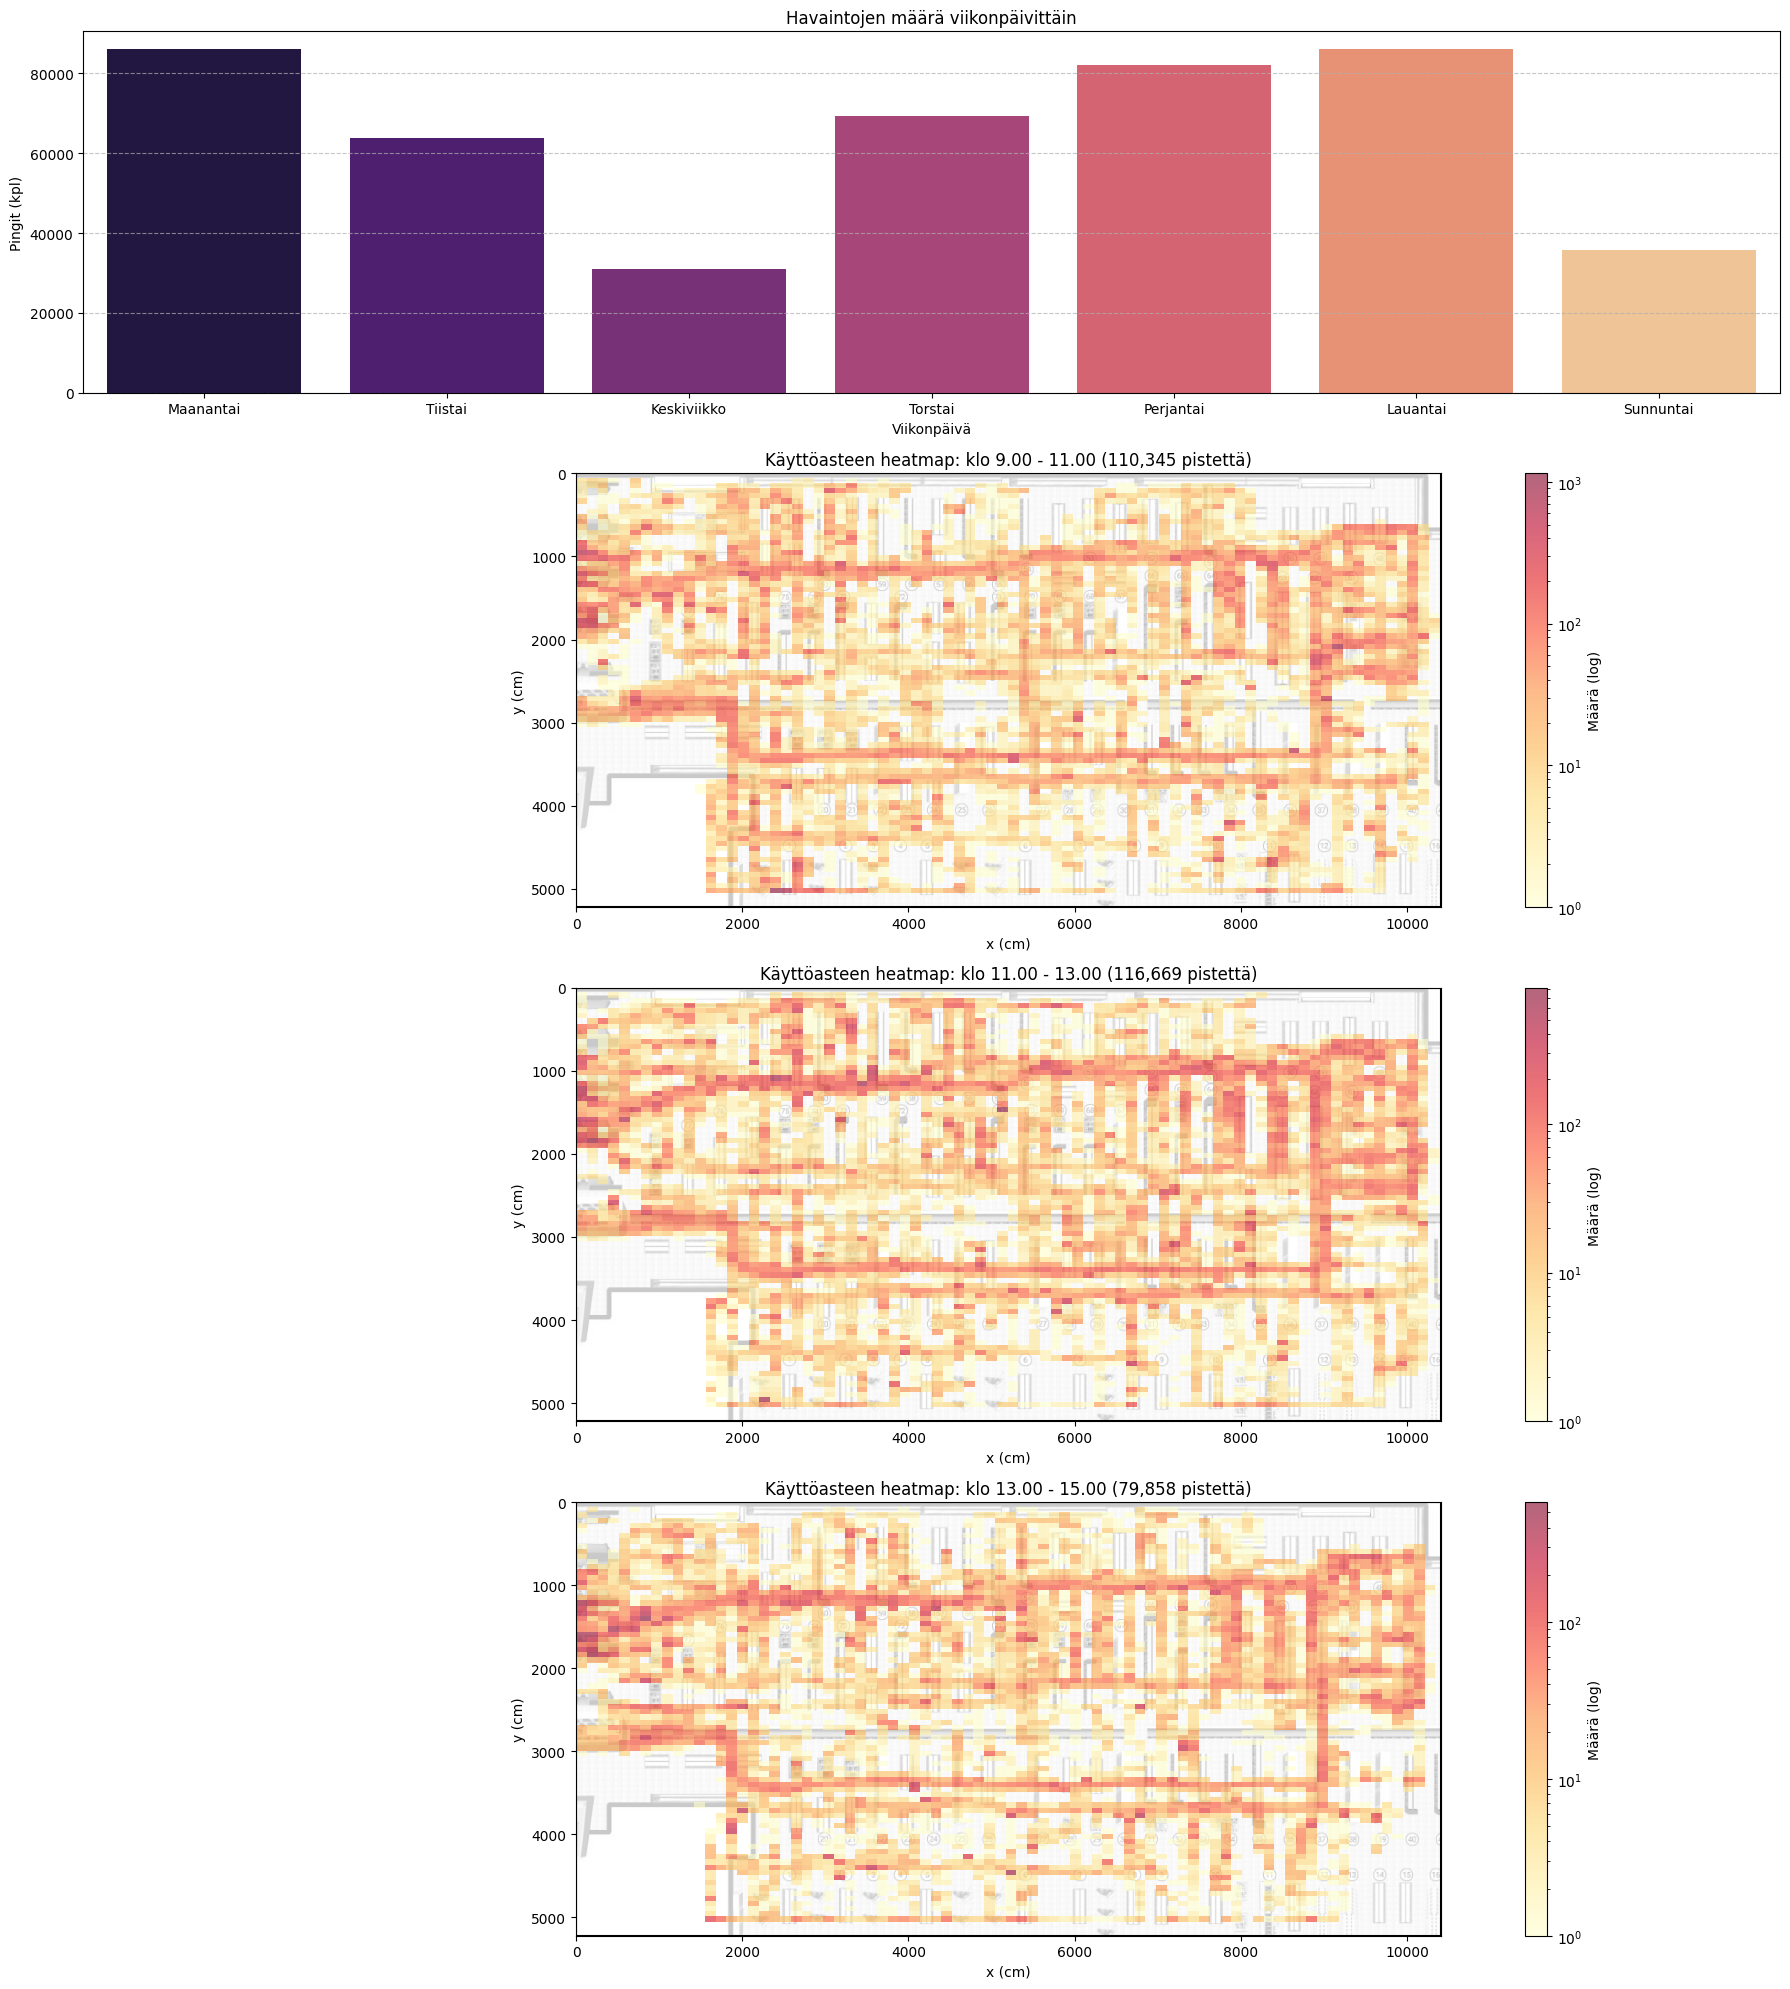

In [5]:
X_MAX = store_config["geometry"]["store_max_x_cm"]
Y_MAX = store_config["geometry"]["store_max_y_cm"]

img_cfg = store_config["geometry"]["image"]
scale = img_cfg["scale_cm_per_px"] * 100 if img_cfg["scale_cm_per_px"] < 1 else img_cfg["scale_cm_per_px"]

img_x_min = -img_cfg["origin_x_px"] * scale
img_x_max = (img_cfg["width_px"] - img_cfg["origin_x_px"]) * scale
img_y_min = -img_cfg["origin_y_px"] * scale
img_y_max = (img_cfg["height_px"] - img_cfg["origin_y_px"]) * scale

# EXT kertoo taustakuvan täydellisen paikan koordinaatistossa
EXT = [img_x_min, img_x_max, img_y_max, img_y_min]

# ── 1. VIIKONPÄIVÄANALYYSI JA HEATMAPIT ──
paiva_jarjestys = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
suomi_paivat = {'Monday': 'Maanantai', 'Tuesday': 'Tiistai', 'Wednesday': 'Keskiviikko', 'Thursday': 'Torstai', 'Friday': 'Perjantai', 'Saturday': 'Lauantai', 'Sunday': 'Sunnuntai'}

ping_counts = df_final.copy()
ping_counts['weekday_en'] = ping_counts['timestamp'].dt.day_name()
daily_ping_summary = ping_counts.groupby('weekday_en').size().reindex(paiva_jarjestys).fillna(0).astype(int).reset_index()
daily_ping_summary.columns = ['Viikonpäivä_EN', 'Pingien_määrä']
daily_ping_summary['Viikonpäivä'] = daily_ping_summary['Viikonpäivä_EN'].map(suomi_paivat)

# Luodaan kuva-alue (1 bar chart + 3 heatmapia)
fig = plt.figure(figsize=(18, 20))
gs = fig.add_gridspec(4, 1, height_ratios=[1, 1.2, 1.2, 1.2])

# Visualisointi 1: Bar Chart
ax1 = fig.add_subplot(gs[0])
sns.barplot(data=daily_ping_summary, x='Viikonpäivä', y='Pingien_määrä', palette='magma', hue='Viikonpäivä', ax=ax1, legend=False)
ax1.set_title('Havaintojen määrä viikonpäivittäin')
ax1.set_ylabel('Pingit (kpl)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Aputoiminto heatmapille
def add_heatmap_to_ax(ax, data, title):
    try:
        # Varmista, että polku kuvaan on oikein ympäristössäsi!
        img = Image.open('../kauppa.jpg') 
        ax.imshow(img, extent=EXT, aspect='equal', alpha=0.4)
    except FileNotFoundError: 
        print("⚠️ Varoitus: kauppa.jpg taustakuvaa ei löytynyt, piirretään pelkkä data.")
        pass

    if not data.empty:
        h = ax.hist2d(data['x'], data['y'], bins=80, cmap='YlOrRd', alpha=0.6, cmin=1, norm=LogNorm())
        fig.colorbar(h[3], ax=ax, label='Määrä (log)')

    ax.plot([0, X_MAX, X_MAX, 0, 0], [0, 0, Y_MAX, Y_MAX, 0], color='black', lw=1.5)
    ax.set_xlim(0, X_MAX)
    ax.set_ylim(Y_MAX, 0)
    ax.set_title(title)
    ax.set_xlabel("x (cm)")
    ax.set_ylabel("y (cm)")

# Aikavälit heatmapille
time_slots = [(9, 11), (11, 13), (13, 15)]
for i, (start_h, end_h) in enumerate(time_slots):
    ax_hm = fig.add_subplot(gs[i+1])
    mask = (df_final['timestamp'].dt.hour >= start_h) & (df_final['timestamp'].dt.hour < end_h)
    slot_df = df_final[mask]
    add_heatmap_to_ax(ax_hm, slot_df, f"Käyttöasteen heatmap: klo {start_h}.00 - {end_h}.00 ({len(slot_df):,} pistettä)")

plt.tight_layout()
plt.show()

# 6. Myymälän käyttöasteen visualisointi

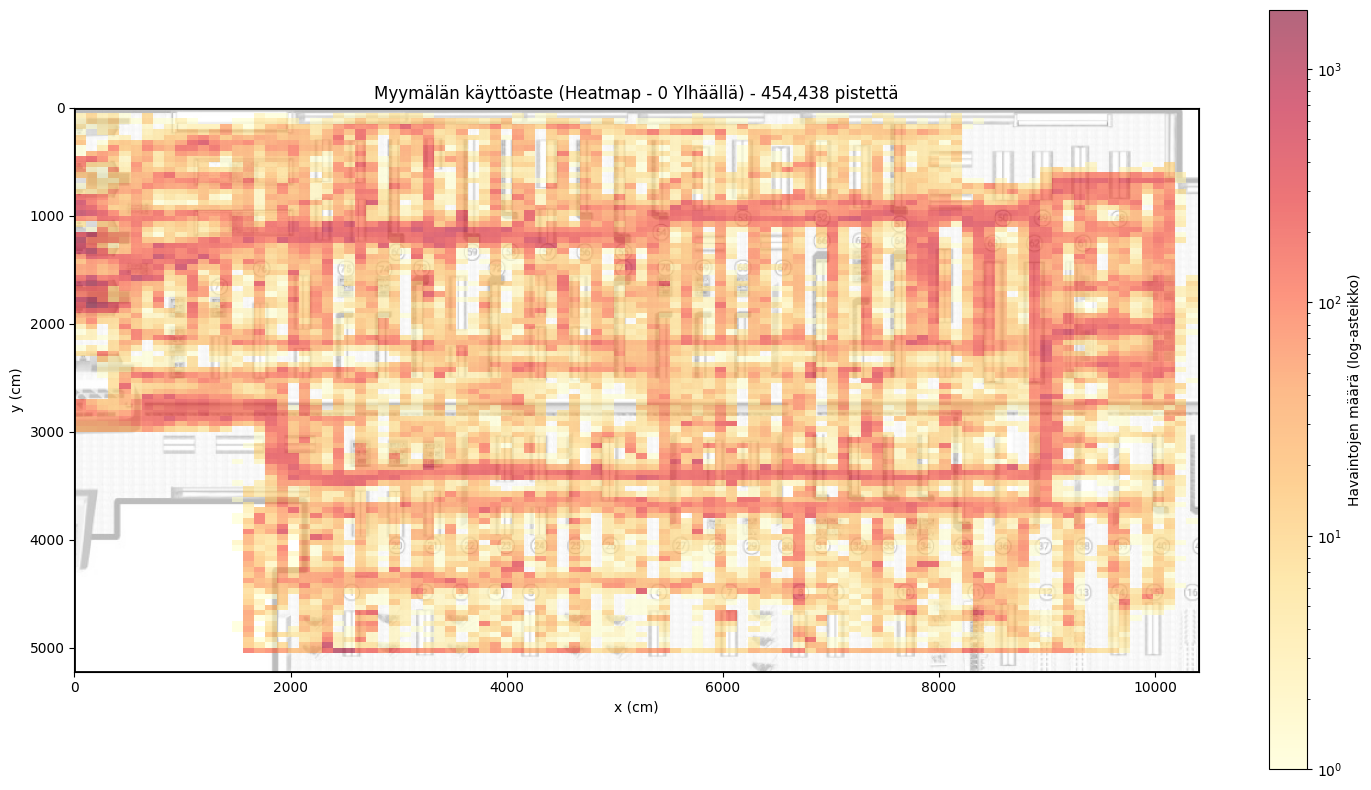

In [6]:
def plot_heatmap(df, bins=60, use_log=True):
    if df.empty:
        print("Ei dataa heatmapia varten.")
        return

    fig, ax = plt.subplots(figsize=(15, 8))

    # Ladataan taustakuva (POLKU KORJATTU)
    try:
        img = Image.open('../kauppa.jpg')
        ax.imshow(img, extent=EXT, aspect='equal', alpha=0.5)
    except Exception as e:
        print(f"Taustakuvaa ei voitu ladata: {e}")

    # Jos heatmap on 'tasapaksu', logaritminen asteikko auttaa näkemään erot
    norm = LogNorm() if use_log else None

    # Luodaan 2D-histogrammi
    h = ax.hist2d(df['x'], df['y'], bins=bins, cmap='YlOrRd',
                  alpha=0.6, cmin=1, norm=norm)

    # Lisätään väripalkki
    plt.colorbar(h[3], ax=ax, label='Havaintojen määrä (log-asteikko)' if use_log else 'Määrä')

    # Piirretään myymälän rajat
    ax.plot([0, X_MAX, X_MAX, 0, 0], [0, 0, Y_MAX, Y_MAX, 0], color='black', lw=2)

    # Palautetaan X alkuperäiseksi (0 vasemmalla) ja pidetään Y käännettynä (0 ylhäällä)
    ax.set_xlim(0, X_MAX)
    ax.set_ylim(Y_MAX, 0)

    plt.title(f"Myymälän käyttöaste (Heatmap - 0 Ylhäällä) - {len(df):,} pistettä")
    plt.xlabel("x (cm)")
    plt.ylabel("y (cm)")
    plt.tight_layout()
    plt.show()

# Piirretään heatmap
plot_heatmap(df_final, bins=100, use_log=True)

# 7. Kassa-alueen ruuhkautuminen

In [7]:
def calculate_checkout_dwell(df):
    # Haetaan kassan koordinaatit konfiguraatiosta
    kassa_coords = store_config['spatial_zones']['gates']['kassa']['coords']
    x1, x2, y1, y2 = kassa_coords

    # Suodatetaan vain kassa-alueen pisteet
    kassa_df = df[(df['x'] >= x1) & (df['x'] <= x2) & (df['y'] >= y1) & (df['y'] <= y2)].copy()

    if kassa_df.empty:
        return "Kassa-alueelta ei löytynyt havaintoja."

    # Lasketaan viipymä per sessio (max t - min t)
    dwell_times = kassa_df.groupby('final_sid')['timestamp'].agg(lambda x: (x.max() - x.min()).total_seconds())

    # Suodatetaan pois 'läpikulut' (alle 10 sekuntia)
    valid_dwells = dwell_times[dwell_times > 10]

    avg_dwell_s = valid_dwells.mean()
    avg_dwell_min = avg_dwell_s / 60

    print(f"--- KASSA-ALUEEN ANALYYSI ---")
    print(f"Havaittuja kassatapahtumia: {len(valid_dwells)} kpl")
    print(f"Keskimääräinen viipymäaika: {avg_dwell_min:.2f} minuuttia ({avg_dwell_s:.1f} sekuntia)")
    print(f"Mediaani viipymäaika: {valid_dwells.median() / 60:.2f} minuuttia")

    return valid_dwells

checkout_dwell_times = calculate_checkout_dwell(df_final)

--- KASSA-ALUEEN ANALYYSI ---
Havaittuja kassatapahtumia: 262 kpl
Keskimääräinen viipymäaika: 5.24 minuuttia (314.4 sekuntia)
Mediaani viipymäaika: 2.08 minuuttia


# 8. Ostosessioiden määrä



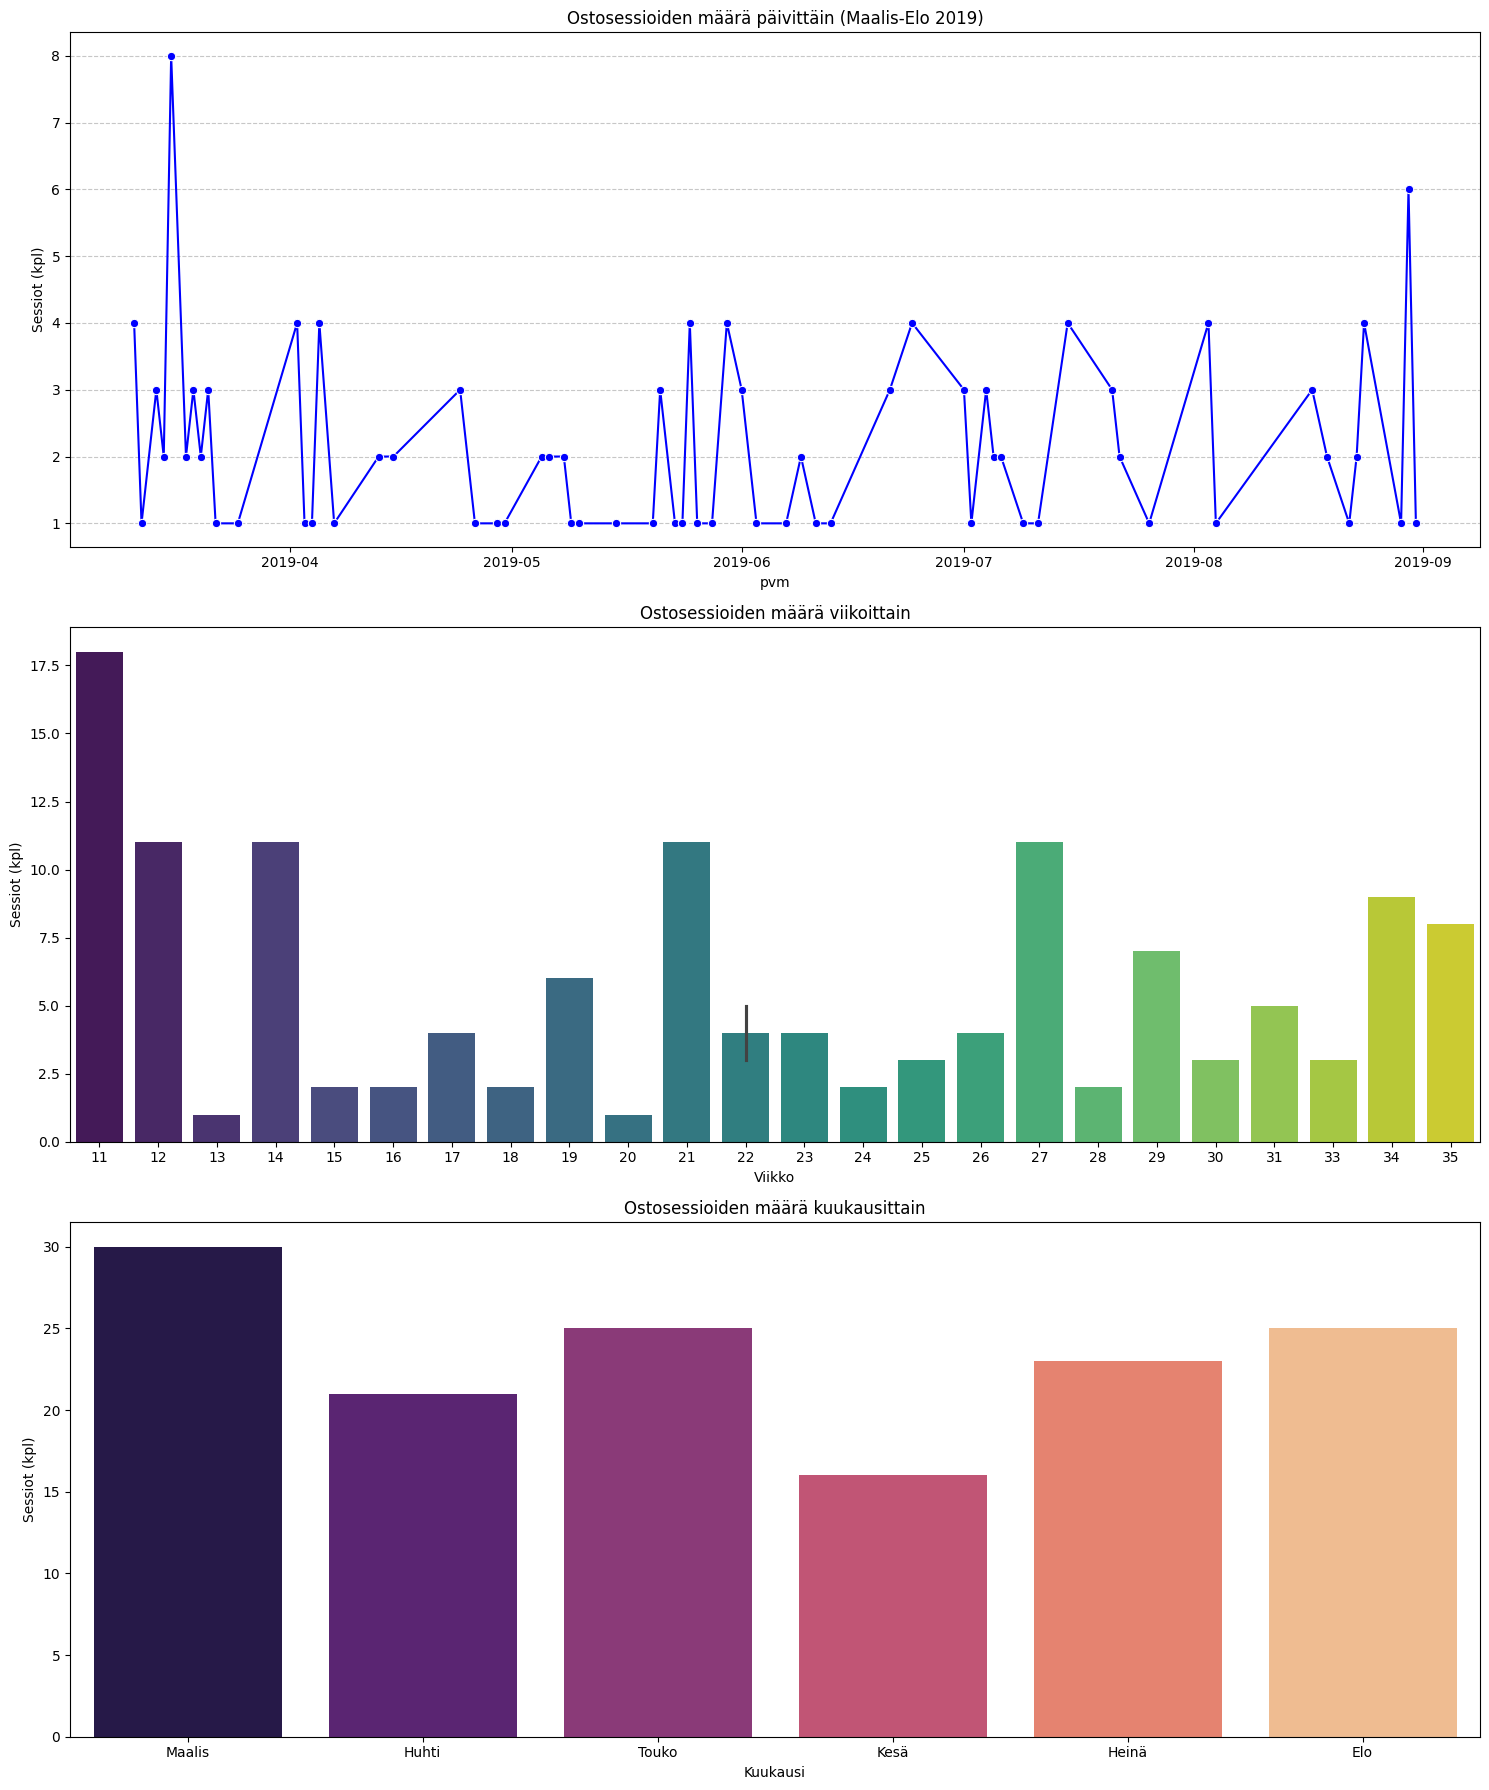

--- KUUKAUSITTAINEN YHTEENVETO ---


,kuukausi,sessio_lkm,kuukausi_nimi
0,3,30,Maalis
1,4,21,Huhti
2,5,25,Touko
3,6,16,Kesä
4,7,23,Heinä
5,8,25,Elo


In [8]:
# ── 1. SUODATUS: KULTAINEN IKKUNA (Maaliskuu - Elokuu 2019) ──
df_stats = session_metrics.copy()
df_stats['pvm'] = pd.to_datetime(df_stats['pvm'])

# Leikataan pois haamudata (voit muuttaa näitä päivämääriä tarvittaessa)
alku_pvm = pd.to_datetime('2019-03-01')
loppu_pvm = pd.to_datetime('2019-08-31')
df_stats = df_stats[(df_stats['pvm'] >= alku_pvm) & (df_stats['pvm'] <= loppu_pvm)].copy()

# ── 2. AIKAMUUTTUJIEN LUONTI ──
df_stats['viikko'] = df_stats['pvm'].dt.isocalendar().week
df_stats['kuukausi'] = df_stats['pvm'].dt.month

# ── 3. AGGREGOINTI JA LAJITTELU (Kronologisen järjestyksen pakotus) ──
# Päivät
daily_counts = df_stats.groupby('pvm').size().reset_index(name='sessio_lkm')
daily_counts = daily_counts.sort_values('pvm')

# Viikot
weekly_counts = df_stats.groupby(['kuukausi', 'viikko']).size().reset_index(name='sessio_lkm')
weekly_counts = weekly_counts.sort_values(['kuukausi', 'viikko'])
weekly_counts['viikko_str'] = weekly_counts['viikko'].astype(str) # Muutetaan tekstiksi Barplotia varten

# Kuukaudet
monthly_counts = df_stats.groupby('kuukausi').size().reset_index(name='sessio_lkm')
monthly_counts = monthly_counts.sort_values('kuukausi')

# Sanakirja kuukausille
kk_mappaus = {
    1: 'Tammi', 2: 'Helmi', 3: 'Maalis', 4: 'Huhti',
    5: 'Touko', 6: 'Kesä', 7: 'Heinä', 8: 'Elo',
    9: 'Syys', 10: 'Loka', 11: 'Marras', 12: 'Joulu'
}
monthly_counts['kuukausi_nimi'] = monthly_counts['kuukausi'].map(kk_mappaus)

# ── 4. VISUALISOINTI ──
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# Päivät
sns.lineplot(data=daily_counts, x='pvm', y='sessio_lkm', ax=axes[0], marker='o', color='blue')
axes[0].set_title('Ostosessioiden määrä päivittäin (Maalis-Elo 2019)')
axes[0].set_ylabel('Sessiot (kpl)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Viikot
sns.barplot(
    data=weekly_counts, x='viikko_str', y='sessio_lkm', 
    ax=axes[1], palette='viridis', hue='viikko_str', legend=False,
    order=weekly_counts['viikko_str'] # Pakottaa datan järjestyksen
)
axes[1].set_title('Ostosessioiden määrä viikoittain')
axes[1].set_ylabel('Sessiot (kpl)')
axes[1].set_xlabel('Viikko')

# Kuukaudet
sns.barplot(
    data=monthly_counts, x='kuukausi_nimi', y='sessio_lkm', 
    ax=axes[2], palette='magma', hue='kuukausi_nimi', legend=False,
    order=monthly_counts['kuukausi_nimi']
)
axes[2].set_title('Ostosessioiden määrä kuukausittain')
axes[2].set_ylabel('Sessiot (kpl)')
axes[2].set_xlabel('Kuukausi')

plt.tight_layout()
plt.show()

print("--- KUUKAUSITTAINEN YHTEENVETO ---")
display(monthly_counts)

# 9. Kassa-alueen liikenne

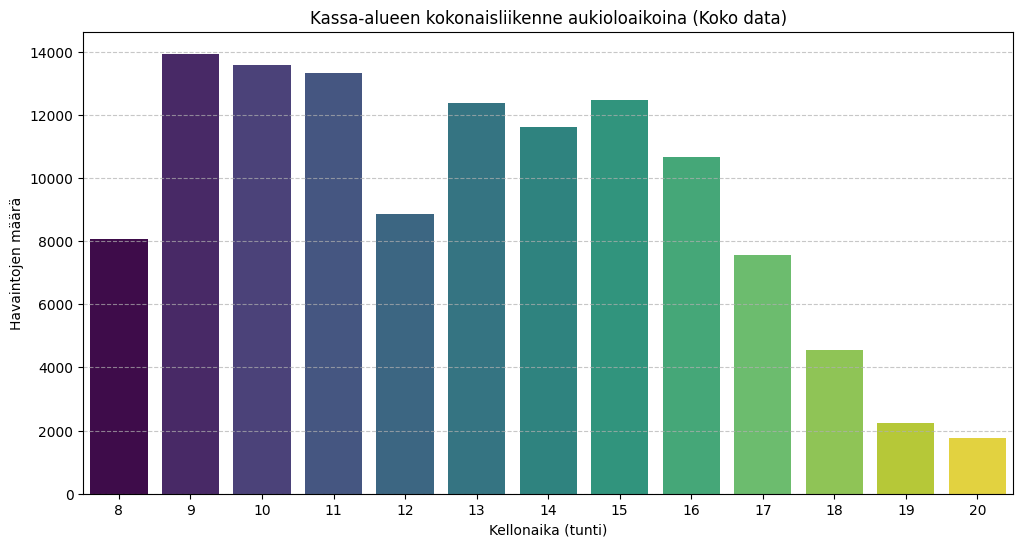

--- KASSA-ALUEEN LIIKENNEHUIPUT (KOKO DATA) ---


,hour,havainto_lkm
1,9,13930
2,10,13566
3,11,13328
7,15,12452
5,13,12379
6,14,11625
8,16,10658
4,12,8850
0,8,8078
9,17,7552


In [9]:
def analyze_full_checkout_traffic(df_raw):
    # 1. Suodatetaan aukioloajat (käytetään olemassa olevaa cleaner-luokkaa tai logiikkaa)
    df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
    df_raw['hour'] = df_raw['timestamp'].dt.hour
    df_raw['weekday'] = df_raw['timestamp'].dt.day_name()

    # Aukiolofiltteri
    def is_open(row):
        start, end = store_config['operational_hours']['sun'] if row['weekday'] == 'Sunday' else store_config['operational_hours']['mon-sat']
        return start <= row['hour'] < end

    # Tehdään suodatus aukioloaikojen mukaan
    df_open = df_raw[df_raw.apply(is_open, axis=1)].copy()

    # 2. Kassan koordinaatit
    kassa_coords = store_config['spatial_zones']['gates']['kassa']['coords']
    x1, x2, y1, y2 = kassa_coords

    # Suodatetaan kassa-alueen pisteet
    kassa_df = df_open[(df_open['x'] >= x1) & (df_open['x'] <= x2) & (df_open['y'] >= y1) & (df_open['y'] <= y2)].copy()

    if kassa_df.empty:
        print("Ei havaintoja kassa-alueelta aukioloaikojen puitteissa.")
        return

    # Lasketaan liikenne (tässä tapauksessa pisteiden tiheys/määrä tai uniikit node_id:t per tunti)
    # Koska kyseessä on koko data ilman sessionisointia, katsotaan havaintojen määrää trendinä
    traffic_stats = kassa_df.groupby('hour').size().reset_index(name='havainto_lkm')

    # Visualisointi
    plt.figure(figsize=(12, 6))
    # Vaihdettu palette 'YlOrBr' -> 'viridis'
    sns.barplot(data=traffic_stats, x='hour', y='havainto_lkm', palette='viridis', hue='hour', legend=False)
    plt.title('Kassa-alueen kokonaisliikenne aukioloaikoina (Koko data)')
    plt.xlabel('Kellonaika (tunti)')
    plt.ylabel('Havaintojen määrä')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    print("--- KASSA-ALUEEN LIIKENNEHUIPUT (KOKO DATA) ---")
    display(traffic_stats.sort_values(by='havainto_lkm', ascending=False))
    return traffic_stats

# Suoritetaan analyysi koko alkuperäisellä datalla (df)
full_checkout_traffic = analyze_full_checkout_traffic(df)